# Hypotises about transaction by game event

## Table of Contents

- [Introduction](#Introduction)
- [Import libraries](#Import-libraries)
- [Creating connection to DB](#Creating-connection-to-DB)
- [Initialize DataFrames](#Initialize-DataFrames)
- [DataFrame Previews](#DataFrame-Previews)
  - [Transaction](#Transaction)
  - [Game Event](#Game-Event)
- [Data Transformation](#Data-Transformation)
  - [DT Transaction](#DT-Transaction)
  - [DT Game Event](#DT-Game-Event)
- [Top level look](#Top-level-look)
- [Statistical Analysis](#Statistical-Analysis)
  - [Game event Transactions](#Game-event-Transactions)
  - [The Winner Of Game Award](#The-Winner-Of-Game-Award)
  - [The Joseph Rebirth](#The-Joseph-Rebirth)
  - [Ghost Invasion](#Ghost-Invasion)
- [Conclusions](#Conclusions)

## Introduction

This notebook presents a statistical analysis of transaction behavior during in-game events, as well as in the periods before and after these events.

The main objective is to investigate whether player transaction patterns change during game events and to identify similarities and differences between transaction distributions across different periods. The analysis focuses on key transaction metrics, distribution characteristics, and statistical significance tests to determine whether observed changes are associated with the events themselves.

## Import libraries

In [1]:
import psycopg2
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats

import warnings
warnings.filterwarnings('ignore')

## Creating connection to DB

In [2]:
conn = psycopg2.connect(
    host="localhost",
    database="gamedev",
    user="postgres",
    password="123456"
)

## Initialize DataFrames

In [3]:
transaction_df = pd.read_sql_query(
    "SELECT * FROM mart.mv_transaction_365d",
    conn
)

game_event_df = pd.read_sql_query(
    "SELECT * FROM core.dim_game_event",
    conn
)

## DataFrame Previews

### Transaction

In [4]:
transaction_df.head()

,id,user_id,date,currency_code,currency_name,price,price_usd,platform,game_event_title,is_game_event_time,created_at,updated_at
0,1,25,2026-04-17,USD,USA Dollar,6,6.00,PC,None,False,2026-06-03,2026-06-03
1,2,392,2026-03-11,EUR,Euro,77,82.39,Android,None,False,2026-06-03,2026-06-03
2,3,331,2026-01-12,USD,USA Dollar,17,17.00,iOS,The Winner Of Game Award,True,2026-06-03,2026-06-03
3,4,171,2026-04-20,EUR,Euro,62,66.34,iOS,None,False,2026-06-03,2026-06-03
4,5,582,2026-04-13,EUR,Euro,93,99.51,Android,None,False,2026-06-03,2026-06-03


In [5]:
transaction_df.describe()

,id,user_id,price,price_usd
count,7000.000000,7000.000000,7000.000000,7000.000000
mean,3500.500000,644.927143,70984.082857,275.739927
std,2020.870275,287.660365,81896.161072,408.944649
min,1.000000,1.000000,5.000000,0.782680
25%,1750.750000,422.000000,62.000000,45.000000
50%,3500.500000,754.000000,31278.000000,86.360000
75%,5250.250000,876.000000,137667.750000,218.558025
max,7000.000000,1000.000000,249934.000000,1574.584200


In [6]:
transaction_df.dtypes

id                      int64
user_id                 int64
date                   object
currency_code          object
currency_name          object
price                   int64
price_usd             float64
platform               object
game_event_title       object
is_game_event_time       bool
created_at             object
updated_at             object
dtype: object

### Game Event

In [7]:
game_event_df

,id,name,start_date,end_date,created_at,updated_at
0,1,The Winner Of Game Award,2026-01-10,2026-01-21,2026-06-03,2026-06-03
1,2,The Joseph Rebirth,2026-02-04,2026-02-17,2026-06-03,2026-06-03
2,3,Ghost Invasion,2026-04-01,2026-04-03,2026-06-03,2026-06-03


In [8]:
game_event_df.dtypes

id             int64
name          object
start_date    object
end_date      object
created_at    object
updated_at    object
dtype: object

## Data Transformation

### DT Transaction

In [9]:
def make_period_no_event_range(row):
    date = row['Transaction date']
    current_event = row['Game event title']

    if current_event != 'No Event':
        return current_event

    for _, event in game_event_df.iterrows():

        start = pd.Timestamp(event['start_date'])
        end = pd.Timestamp(event['end_date'])
        name = event['name']

        duration = (end - start).days

        before_start = start - pd.Timedelta(days=duration)
        after_end = end + pd.Timedelta(days=duration)

        if before_start <= date < start:
            return f'{duration} days before {name}'

        if end < date <= after_end:
            return f'{duration} days after {name}'

    return 'No Event'

columns = ['user_id', 'date', 'price_usd', 'game_event_title', 'is_game_event_time']

transaction_df = transaction_df[columns]
transaction_df['date'] = pd.to_datetime(transaction_df['date'])
transaction_df['price_usd'] = transaction_df['price_usd'].round(0)
transaction_df['price_usd'] = transaction_df['price_usd'].astype(int)

transaction_df['game_event_title'].fillna('No Event', inplace=True)

transaction_df.rename(
    columns={
        'user_id': 'User ID',
        'price_usd': 'Price USD',
        'date': 'Transaction date',
        'game_event_title': 'Game event title',
        'is_game_event_time': 'Is game event time'
    },
    inplace=True
)

transaction_df['Game event title'] = transaction_df.apply(make_period_no_event_range, axis=1)

transaction_df.head()

,User ID,Transaction date,Price USD,Game event title,Is game event time
0,25,2026-04-17,6,No Event,False
1,392,2026-03-11,82,No Event,False
2,331,2026-01-12,17,The Winner Of Game Award,True
3,171,2026-04-20,66,No Event,False
4,582,2026-04-13,100,No Event,False


In [10]:
transaction_df.dtypes

User ID                        int64
Transaction date      datetime64[ns]
Price USD                      int32
Game event title              object
Is game event time              bool
dtype: object

### DT Game Event

In [11]:
game_event_df = game_event_df.iloc[:, 1:-2]
game_event_df['start_date'] = pd.to_datetime(game_event_df['start_date'])
game_event_df['end_date'] = pd.to_datetime(game_event_df['end_date'])

game_event_df['Days duration'] = (game_event_df['end_date'] - game_event_df['start_date']).dt.days
game_event_df

,name,start_date,end_date,Days duration
0,The Winner Of Game Award,2026-01-10,2026-01-21,11
1,The Joseph Rebirth,2026-02-04,2026-02-17,13
2,Ghost Invasion,2026-04-01,2026-04-03,2


## Top level look

In [12]:
tmp_df = (
    transaction_df
    .groupby('Game event title')
    .agg(
        Total_amount=('Price USD', 'sum'),
        Transaction_count=('Price USD', 'count'),
        Mean=('Price USD', 'mean'),
        Q25=('Price USD', lambda x: x.quantile(0.25)),
        Q50=('Price USD', lambda x: x.quantile(0.50)),
        Q75=('Price USD', lambda x: x.quantile(0.75)),
        Q90=('Price USD', lambda x: x.quantile(0.90)),
        Q95=('Price USD', lambda x: x.quantile(0.95))
    )
    .reset_index()
    .merge(
        game_event_df,
        left_on='Game event title',
        right_on='name',
        how='left'
    )
)

for col in [
    'Mean',
    'Q25',
    'Q50',
    'Q75',
    'Q90',
    'Q95'
]:
    tmp_df[col] = tmp_df[col].round(0)

tmp_df['Days duration'] = tmp_df['Days duration'].fillna(
    tmp_df['Game event title'].str.extract(r'(\d+)\s+days')[0].astype(float)
)

tmp_df['Average amount per day'] = (
    tmp_df['Total_amount'] / tmp_df['Days duration']
).round(0)

tmp_df = (
    tmp_df.rename(columns={
        'Game event title': 'Event'
    })
    [[
        'Event',
        'Days duration',
        'Transaction_count',
        'Mean',
        'Q25',
        'Q50',
        'Q75',
        'Q90',
        'Q95',
        'Total_amount',
        'Average amount per day'
    ]]
)

tmp_df

,Event,Days duration,Transaction_count,Mean,Q25,Q50,Q75,Q90,Q95,Total_amount,Average amount per day
0,11 days after The Winner Of Game Award,11.0,689,282.0,50.0,90.0,284.0,987.0,1286.0,194550,17686.0
1,11 days before The Winner Of Game Award,11.0,566,251.0,44.0,83.0,169.0,934.0,1196.0,142263,12933.0
2,13 days after The Joseph Rebirth,13.0,847,277.0,47.0,88.0,240.0,1088.0,1299.0,235019,18078.0
3,13 days before The Joseph Rebirth,13.0,135,301.0,46.0,97.0,303.0,1051.0,1289.0,40578,3121.0
4,2 days after Ghost Invasion,2.0,115,238.0,54.0,92.0,148.0,935.0,1232.0,27379,13690.0
5,2 days before Ghost Invasion,2.0,137,268.0,39.0,78.0,164.0,1034.0,1422.0,36718,18359.0
6,Ghost Invasion,2.0,141,240.0,53.0,84.0,152.0,967.0,1218.0,33878,16939.0
7,No Event,NaN,2857,280.0,44.0,85.0,223.0,1049.0,1341.0,799875,NaN
8,The Joseph Rebirth,13.0,777,278.0,43.0,88.0,251.0,994.0,1305.0,216154,16627.0
9,The Winner Of Game Award,11.0,736,277.0,43.0,85.0,204.0,1084.0,1294.0,203786,18526.0


## Statistical Analysis

### Game event Transactions

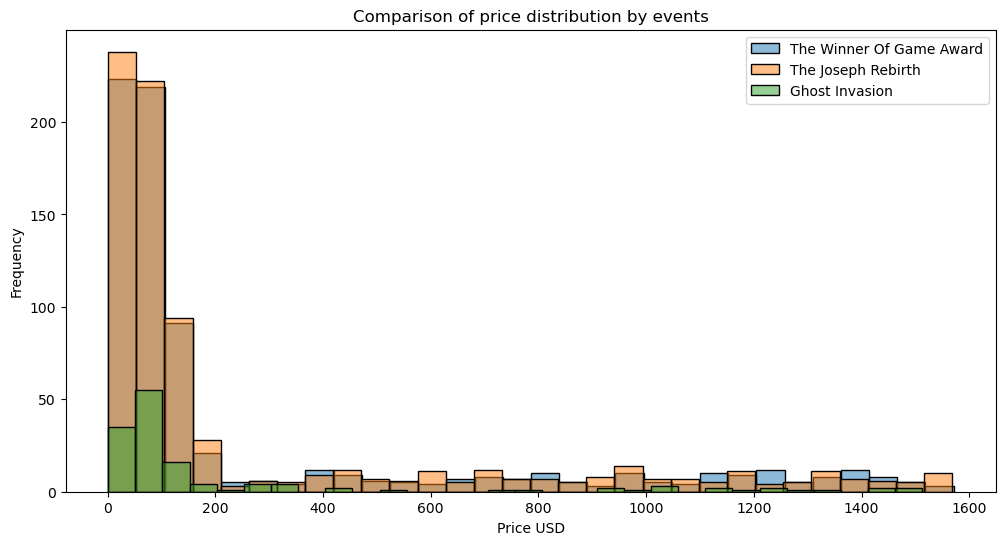

In [13]:
events = [
    'The Winner Of Game Award',
    'The Joseph Rebirth', 
    'Ghost Invasion'
         ]

plt.figure(figsize=(12, 6))

for event in events:
    subset = transaction_df[transaction_df['Game event title'] == event]
    sns.histplot(data=subset, x='Price USD', bins=30, label=event, alpha=0.5)

plt.title('Comparison of price distribution by events')
plt.xlabel('Price USD')
plt.ylabel('Frequency')
plt.legend()
plt.show()

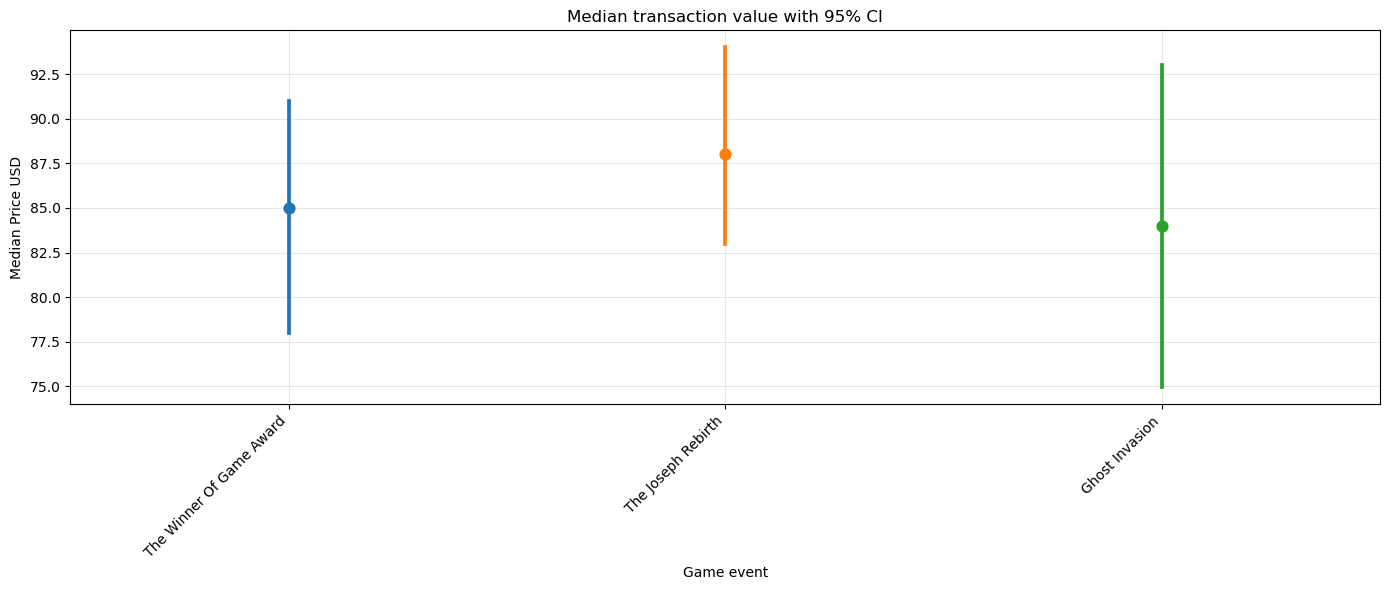

In [14]:
plt.figure(figsize=(14, 6))

sns.pointplot(
    data=transaction_df[transaction_df['Game event title'].isin(events)],
    x='Game event title',
    y='Price USD',
    hue='Game event title',
    estimator=np.median,
    errorbar=('ci', 95),
    dodge=False,
    markers="o",
    linestyles="-"
)

plt.xticks(rotation=45, ha='right')
plt.title('Median transaction value with 95% CI')
plt.xlabel('Game event')
plt.ylabel('Median Price USD')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**The mean and median value of transaction in game events looks the same. Also the histogram shows event transactions has the common pattern. Let's check hypotises**

**H_0:** the transaction behaivor in each game event doesn't have difference

**H_1:** the transaction behaivor in each game event are not the same

In [15]:
event1 = transaction_df[transaction_df['Game event title'] == events[0]]['Price USD']
event2 = transaction_df[transaction_df['Game event title'] == events[1]]['Price USD']
event3 = transaction_df[transaction_df['Game event title'] == events[2]]['Price USD']

stat, p = stats.kruskal(
    event1,
    event2,
    event3
)

print(f"H Test value: {round(stat, 2)}")

print(f"P value: {round(p, 2)}")

if p <= 0.05:
    print("H_1 Hypotises is more statisticaly correct")
else:
    print("H_0 Hypotises is more statisticaly correct")

H Test value: 0.45
P value: 0.8
H_0 Hypotises is more statisticaly correct


#### The Winner of Game Award vs Joseph Rebrith

In [16]:
stat, p = stats.mannwhitneyu(
    event1,
    event2
)

print(f"H Test value: {round(stat, 2)}")

print(f"P value: {round(p, 2)}")

if p <= 0.05:
    print("H_1 Hypotises is more statisticaly correct")
else:
    print("H_0 Hypotises is more statisticaly correct")

H Test value: 280778.5
P value: 0.54
H_0 Hypotises is more statisticaly correct


#### The Winner of Game Award vs Ghost Invasion

In [17]:
stat, p = stats.mannwhitneyu(
    event1,
    event3
)

print(f"H Test value: {round(stat, 2)}")

print(f"P value: {round(p, 2)}")

if p <= 0.05:
    print("H_1 Hypotises is more statisticaly correct")
else:
    print("H_0 Hypotises is more statisticaly correct")

H Test value: 51985.0
P value: 0.97
H_0 Hypotises is more statisticaly correct


#### Joseph Rebrith vs Ghost Invasion

In [18]:
stat, p = stats.mannwhitneyu(
    event2,
    event3
)

print(f"H Test value: {round(stat, 2)}")

print(f"P value: {round(p, 2)}")

if p <= 0.05:
    print("H_1 Hypotises is more statisticaly correct")
else:
    print("H_0 Hypotises is more statisticaly correct")

H Test value: 56078.5
P value: 0.65
H_0 Hypotises is more statisticaly correct


### The Winner Of Game Award

In [19]:
events = [
    '11 days before The Winner Of Game Award',
    '11 days after The Winner Of Game Award',
    'The Winner Of Game Award'
]

tmp_df[tmp_df['Event'].isin(events)]

,Event,Days duration,Transaction_count,Mean,Q25,Q50,Q75,Q90,Q95,Total_amount,Average amount per day
0,11 days after The Winner Of Game Award,11.0,689,282.0,50.0,90.0,284.0,987.0,1286.0,194550,17686.0
1,11 days before The Winner Of Game Award,11.0,566,251.0,44.0,83.0,169.0,934.0,1196.0,142263,12933.0
9,The Winner Of Game Award,11.0,736,277.0,43.0,85.0,204.0,1084.0,1294.0,203786,18526.0


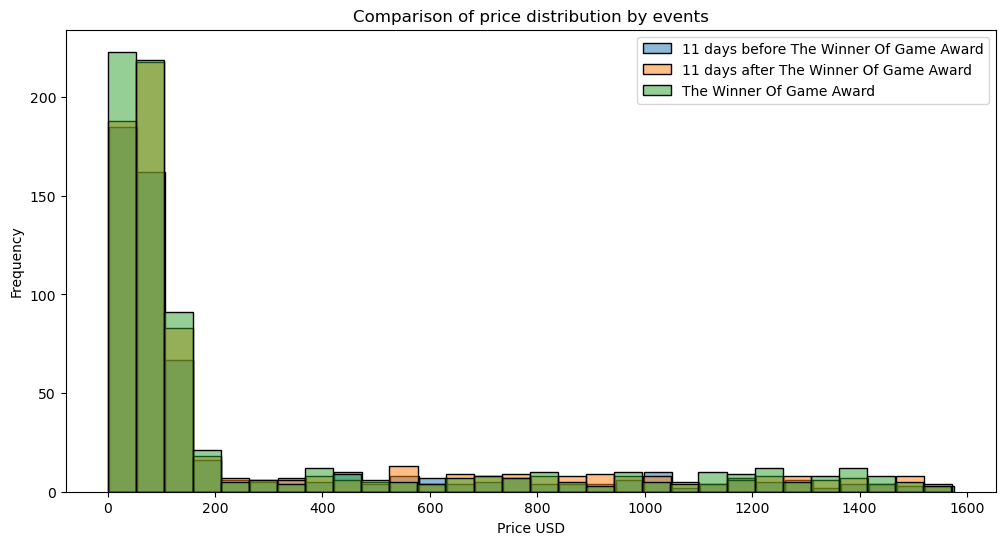

In [20]:
plt.figure(figsize=(12, 6))

for event in events:
    subset = transaction_df[transaction_df['Game event title'] == event]
    sns.histplot(data=subset, x='Price USD', bins=30, label=event, alpha=0.5)

plt.title('Comparison of price distribution by events')
plt.xlabel('Price USD')
plt.ylabel('Frequency')
plt.legend()
plt.show()

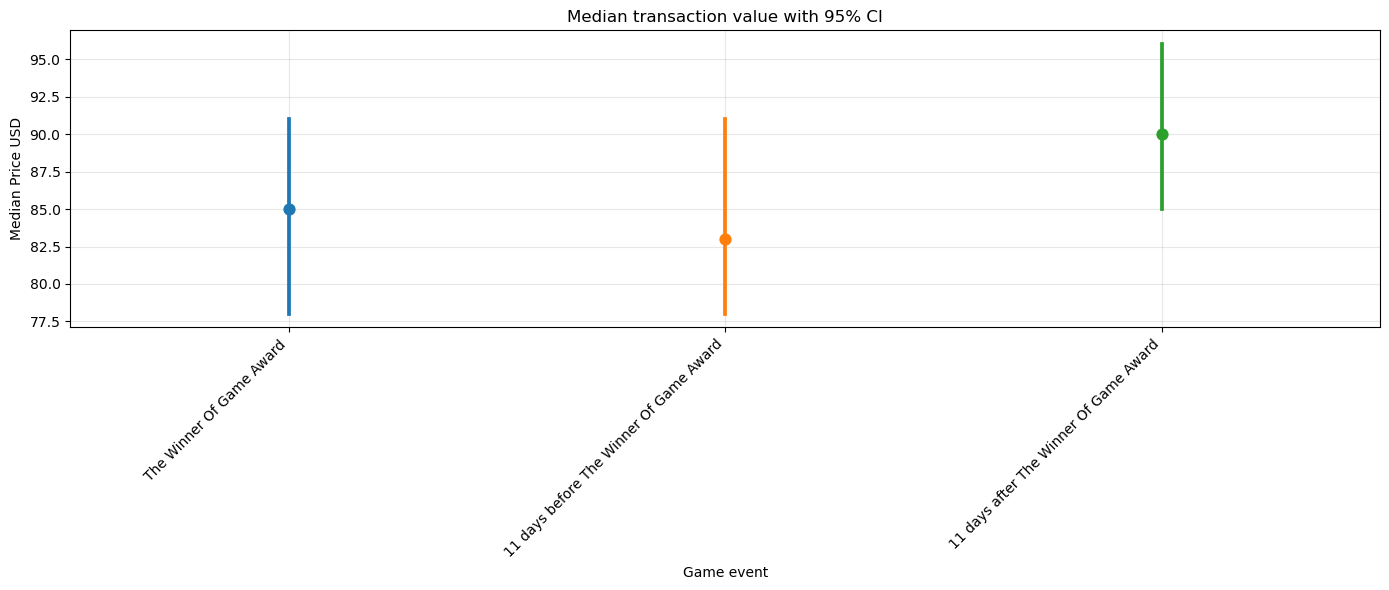

In [21]:
plt.figure(figsize=(14, 6))

sns.pointplot(
    data=transaction_df[transaction_df['Game event title'].isin(events)],
    x='Game event title',
    y='Price USD',
    hue='Game event title',
    estimator=np.median,
    errorbar=('ci', 95),
    dodge=False,
    markers="o",
    linestyles="-"
)

plt.xticks(rotation=45, ha='right')
plt.title('Median transaction value with 95% CI')
plt.xlabel('Game event')
plt.ylabel('Median Price USD')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
event1 = transaction_df[transaction_df['Game event title'] == events[0]]['Price USD']
event2 = transaction_df[transaction_df['Game event title'] == events[1]]['Price USD']
event3 = transaction_df[transaction_df['Game event title'] == events[2]]['Price USD']

stat, p = stats.kruskal(
    event1,
    event2,
    event3
)

print(f"H Test value: {round(stat, 2)}")

print(f"P value: {round(p, 2)}")

if p <= 0.05:
    print("H_1 Hypotises is more statisticaly correct")
else:
    print("H_0 Hypotises is more statisticaly correct")

H Test value: 2.76
P value: 0.25
H_0 Hypotises is more statisticaly correct


#### Before vs Event

In [23]:
stat, p = stats.mannwhitneyu(
    event1,
    event3
)

print(f"H Test value: {round(stat, 2)}")

print(f"P value: {round(p, 2)}")

if p <= 0.05:
    print("H_1 Hypotises is more statisticaly correct")
else:
    print("H_0 Hypotises is more statisticaly correct")

H Test value: 205891.0
P value: 0.72
H_0 Hypotises is more statisticaly correct


#### After vs Event

In [24]:
stat, p = stats.mannwhitneyu(
    event2,
    event3
)

print(f"H Test value: {round(stat, 2)}")

print(f"P value: {round(p, 2)}")

if p <= 0.05:
    print("H_1 Hypotises is more statisticaly correct")
else:
    print("H_0 Hypotises is more statisticaly correct")

H Test value: 263239.0
P value: 0.21
H_0 Hypotises is more statisticaly correct


#### Before vs After

In [25]:
stat, p = stats.mannwhitneyu(
    event1,
    event2
)

print(f"H Test value: {round(stat, 2)}")

print(f"P value: {round(p, 2)}")

if p <= 0.05:
    print("H_1 Hypotises is more statisticaly correct")
else:
    print("H_0 Hypotises is more statisticaly correct")

H Test value: 184918.5
P value: 0.12
H_0 Hypotises is more statisticaly correct


### The Joseph Rebirth

In [26]:
events = [
    '13 days before The Joseph Rebirth',
    '13 days after The Joseph Rebirth',
    'The Joseph Rebirth'
]

tmp_df[tmp_df['Event'].isin(events)]

,Event,Days duration,Transaction_count,Mean,Q25,Q50,Q75,Q90,Q95,Total_amount,Average amount per day
2,13 days after The Joseph Rebirth,13.0,847,277.0,47.0,88.0,240.0,1088.0,1299.0,235019,18078.0
3,13 days before The Joseph Rebirth,13.0,135,301.0,46.0,97.0,303.0,1051.0,1289.0,40578,3121.0
8,The Joseph Rebirth,13.0,777,278.0,43.0,88.0,251.0,994.0,1305.0,216154,16627.0


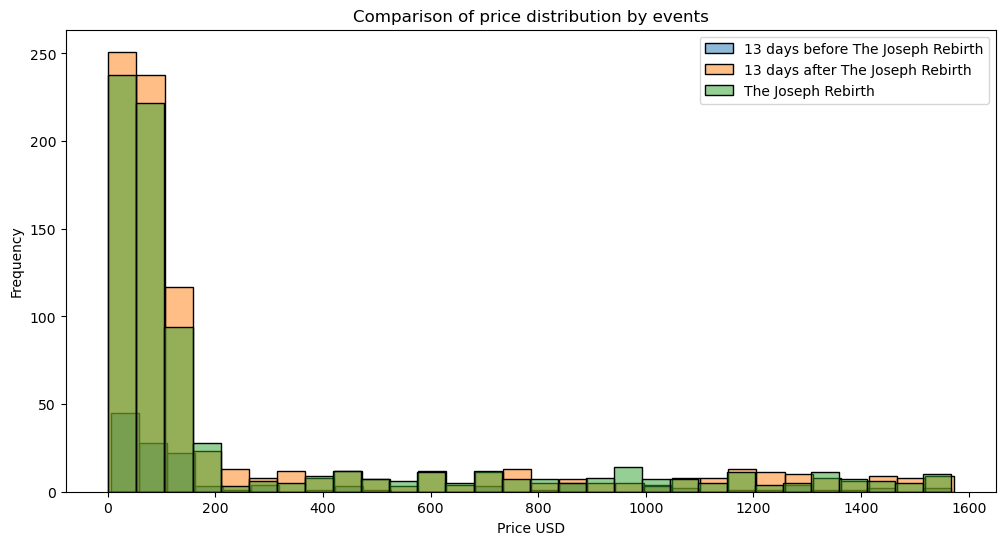

In [27]:
plt.figure(figsize=(12, 6))

for event in events:
    subset = transaction_df[transaction_df['Game event title'] == event]
    sns.histplot(data=subset, x='Price USD', bins=30, label=event, alpha=0.5)

plt.title('Comparison of price distribution by events')
plt.xlabel('Price USD')
plt.ylabel('Frequency')
plt.legend()
plt.show()

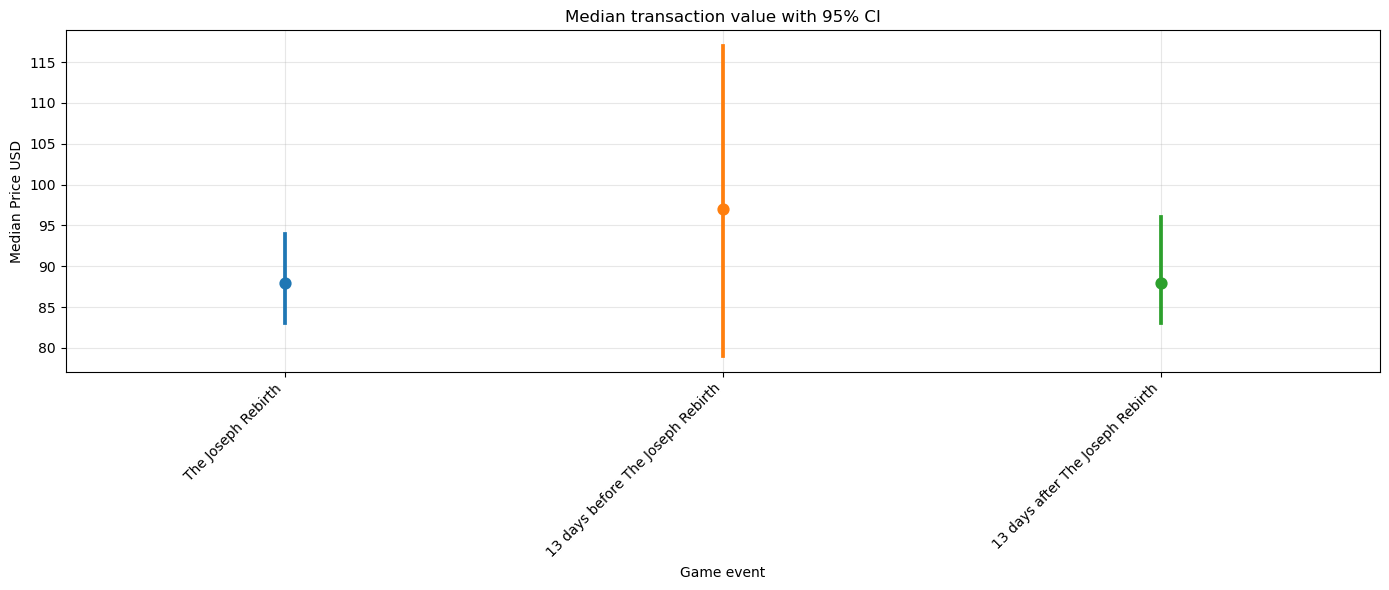

In [28]:
plt.figure(figsize=(14, 6))

sns.pointplot(
    data=transaction_df[transaction_df['Game event title'].isin(events)],
    x='Game event title',
    y='Price USD',
    hue='Game event title',
    estimator=np.median,
    errorbar=('ci', 95),
    dodge=False,
    markers="o",
    linestyles="-"
)

plt.xticks(rotation=45, ha='right')
plt.title('Median transaction value with 95% CI')
plt.xlabel('Game event')
plt.ylabel('Median Price USD')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
event1 = transaction_df[transaction_df['Game event title'] == events[0]]['Price USD']
event2 = transaction_df[transaction_df['Game event title'] == events[1]]['Price USD']
event3 = transaction_df[transaction_df['Game event title'] == events[2]]['Price USD']

stat, p = stats.kruskal(
    event1,
    event2,
    event3
)

print(f"H Test value: {round(stat, 2)}")

print(f"P value: {round(p, 2)}")

if p <= 0.05:
    print("H_1 Hypotises is more statisticaly correct")
else:
    print("H_0 Hypotises is more statisticaly correct")

H Test value: 0.78
P value: 0.68
H_0 Hypotises is more statisticaly correct


#### Before vs Event

In [30]:
stat, p = stats.mannwhitneyu(
    event1,
    event3
)

print(f"H Test value: {round(stat, 2)}")

print(f"P value: {round(p, 2)}")

if p <= 0.05:
    print("H_1 Hypotises is more statisticaly correct")
else:
    print("H_0 Hypotises is more statisticaly correct")

H Test value: 54957.0
P value: 0.37
H_0 Hypotises is more statisticaly correct


#### After vs Event

In [31]:
stat, p = stats.mannwhitneyu(
    event2,
    event3
)

print(f"H Test value: {round(stat, 2)}")

print(f"P value: {round(p, 2)}")

if p <= 0.05:
    print("H_1 Hypotises is more statisticaly correct")
else:
    print("H_0 Hypotises is more statisticaly correct")

H Test value: 329916.0
P value: 0.93
H_0 Hypotises is more statisticaly correct


#### Before vs After

In [32]:
stat, p = stats.mannwhitneyu(
    event1,
    event2
)

print(f"H Test value: {round(stat, 2)}")

print(f"P value: {round(p, 2)}")

if p <= 0.05:
    print("H_1 Hypotises is more statisticaly correct")
else:
    print("H_0 Hypotises is more statisticaly correct")

H Test value: 59636.0
P value: 0.42
H_0 Hypotises is more statisticaly correct


### Ghost Invasion

In [33]:
events = [
    '2 days before Ghost Invasion',
    '2 days after Ghost Invasion',
    'Ghost Invasion'
]

tmp_df[tmp_df['Event'].isin(events)]

,Event,Days duration,Transaction_count,Mean,Q25,Q50,Q75,Q90,Q95,Total_amount,Average amount per day
4,2 days after Ghost Invasion,2.0,115,238.0,54.0,92.0,148.0,935.0,1232.0,27379,13690.0
5,2 days before Ghost Invasion,2.0,137,268.0,39.0,78.0,164.0,1034.0,1422.0,36718,18359.0
6,Ghost Invasion,2.0,141,240.0,53.0,84.0,152.0,967.0,1218.0,33878,16939.0


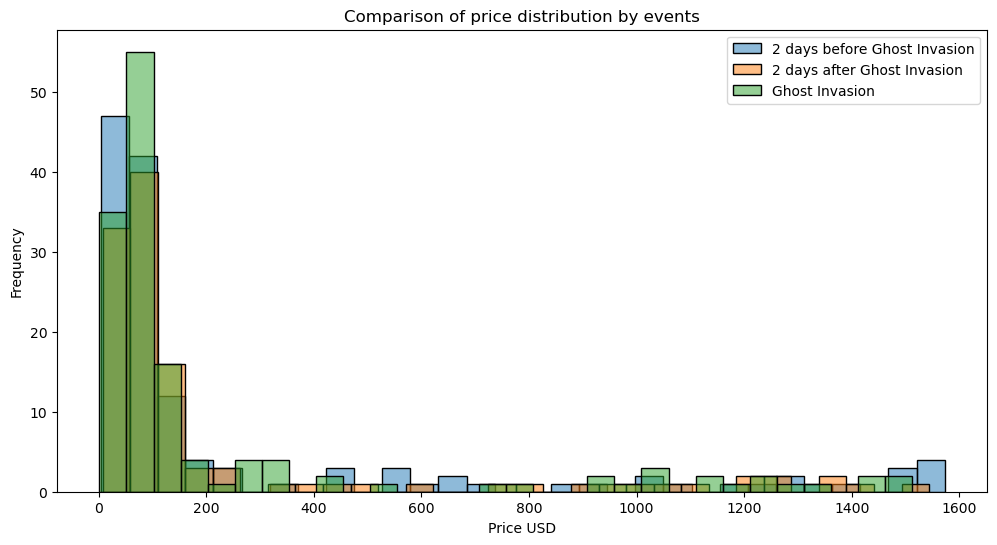

In [34]:
plt.figure(figsize=(12, 6))

for event in events:
    subset = transaction_df[transaction_df['Game event title'] == event]
    sns.histplot(data=subset, x='Price USD', bins=30, label=event, alpha=0.5)

plt.title('Comparison of price distribution by events')
plt.xlabel('Price USD')
plt.ylabel('Frequency')
plt.legend()
plt.show()

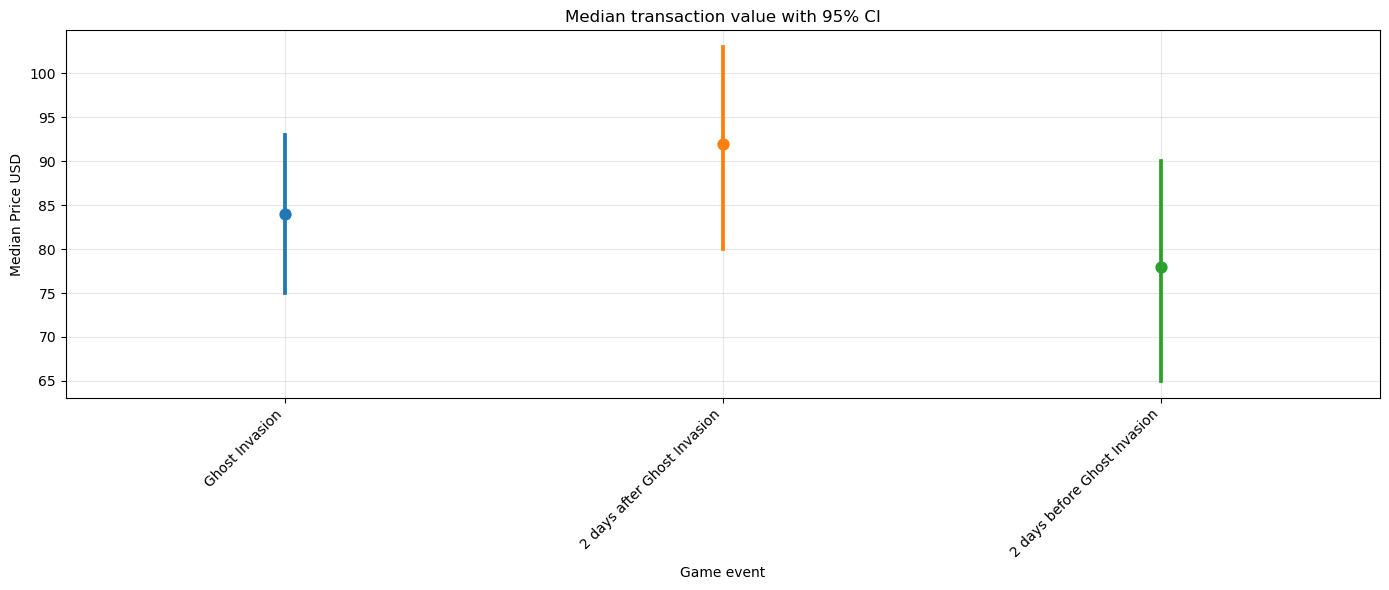

In [35]:
plt.figure(figsize=(14, 6))

sns.pointplot(
    data=transaction_df[transaction_df['Game event title'].isin(events)],
    x='Game event title',
    y='Price USD',
    hue='Game event title',
    estimator=np.median,
    errorbar=('ci', 95),
    dodge=False,
    markers="o",
    linestyles="-"
)

plt.xticks(rotation=45, ha='right')
plt.title('Median transaction value with 95% CI')
plt.xlabel('Game event')
plt.ylabel('Median Price USD')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [36]:
event1 = transaction_df[transaction_df['Game event title'] == events[0]]['Price USD']
event2 = transaction_df[transaction_df['Game event title'] == events[1]]['Price USD']
event3 = transaction_df[transaction_df['Game event title'] == events[2]]['Price USD']

stat, p = stats.kruskal(
    event1,
    event2,
    event3
)

print(f"H Test value: {round(stat, 2)}")

print(f"P value: {round(p, 2)}")

if p <= 0.05:
    print("H_1 Hypotises is more statisticaly correct")
else:
    print("H_0 Hypotises is more statisticaly correct")

H Test value: 1.3
P value: 0.52
H_0 Hypotises is more statisticaly correct


#### Before vs Event

In [37]:
stat, p = stats.mannwhitneyu(
    event1,
    event3
)

print(f"H Test value: {round(stat, 2)}")

print(f"P value: {round(p, 2)}")

if p <= 0.05:
    print("H_1 Hypotises is more statisticaly correct")
else:
    print("H_0 Hypotises is more statisticaly correct")

H Test value: 9190.0
P value: 0.48
H_0 Hypotises is more statisticaly correct


#### After vs Event

In [38]:
stat, p = stats.mannwhitneyu(
    event2,
    event3
)

print(f"H Test value: {round(stat, 2)}")

print(f"P value: {round(p, 2)}")

if p <= 0.05:
    print("H_1 Hypotises is more statisticaly correct")
else:
    print("H_0 Hypotises is more statisticaly correct")

H Test value: 8405.0
P value: 0.61
H_0 Hypotises is more statisticaly correct


#### Before vs After

In [39]:
stat, p = stats.mannwhitneyu(
    event1,
    event2
)

print(f"H Test value: {round(stat, 2)}")

print(f"P value: {round(p, 2)}")

if p <= 0.05:
    print("H_1 Hypotises is more statisticaly correct")
else:
    print("H_0 Hypotises is more statisticaly correct")

H Test value: 7240.5
P value: 0.27
H_0 Hypotises is more statisticaly correct


## Conclusions

Based on the statistical analysis, there is no evidence of significant differences in transaction behavior between event and non-event periods. Across all conducted tests, the null hypothesis could not be rejected, indicating that transaction distributions remain statistically similar regardless of whether a game event is active.

Therefore, the results suggest that in-game events do not have a statistically significant impact on player transaction behavior within the analyzed dataset.